# Step 3 - Missing Values and Timestamp Gaps

This notebook audits the PJM East hourly series for missing timestamps, missing demand values, and duplicate timestamps. The goal is to create a regular hourly time series that can be used safely in the later stationarity and SARIMA steps.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROCESSED_PATH = "../data/processed/"
FIGURES_PATH = "../reports/figures/"

os.makedirs(FIGURES_PATH, exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

df = pd.read_csv(
    os.path.join(PROCESSED_PATH, "pjme_clean.csv"),
    parse_dates=["Datetime"],
    index_col="Datetime",
).sort_index()

df["PJME_MW"] = df["PJME_MW"].astype(float)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

df.head()

Shape: (145366, 1)
Date range: 2002-01-01 01:00:00 to 2018-08-03 00:00:00


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [2]:
full_index = pd.date_range(df.index.min(), df.index.max(), freq="h")
missing_timestamps = full_index.difference(df.index)
duplicate_rows = df.index[df.index.duplicated(keep=False)]
duplicate_timestamps = pd.Index(sorted(duplicate_rows.unique()))

audit_summary = pd.DataFrame(
    {
        "metric": [
            "observed_rows",
            "expected_rows_full_hourly_index",
            "missing_values_in_PJME_MW",
            "missing_timestamps",
            "duplicate_rows",
            "duplicate_unique_timestamps",
        ],
        "value": [
            len(df),
            len(full_index),
            int(df["PJME_MW"].isna().sum()),
            len(missing_timestamps),
            int(df.index.duplicated().sum()),
            len(duplicate_timestamps),
        ],
    }
)

display(audit_summary)
print("First 10 missing timestamps:")
print(missing_timestamps[:10].tolist())

,metric,value
0,observed_rows,145366
1,expected_rows_full_hourly_index,145392
2,missing_values_in_PJME_MW,0
3,missing_timestamps,30
4,duplicate_rows,4
5,duplicate_unique_timestamps,4


First 10 missing timestamps:
[Timestamp('2002-04-07 03:00:00'), Timestamp('2002-10-27 02:00:00'), Timestamp('2003-04-06 03:00:00'), Timestamp('2003-10-26 02:00:00'), Timestamp('2004-04-04 03:00:00'), Timestamp('2004-10-31 02:00:00'), Timestamp('2005-04-03 03:00:00'), Timestamp('2005-10-30 02:00:00'), Timestamp('2006-04-02 03:00:00'), Timestamp('2006-10-29 02:00:00')]


There are no missing values inside the `PJME_MW` column itself, but the hourly index is not perfectly regular. The audit shows 30 missing timestamps and 4 duplicated timestamps, so the main issue is timestamp continuity rather than blank demand cells.

In [3]:
missing_events = pd.DataFrame({"missing_timestamp": missing_timestamps})
missing_events["year"] = missing_events["missing_timestamp"].dt.year
missing_events["month"] = missing_events["missing_timestamp"].dt.month
missing_events["day"] = missing_events["missing_timestamp"].dt.day
missing_events["hour"] = missing_events["missing_timestamp"].dt.hour
missing_events["day_of_week"] = missing_events["missing_timestamp"].dt.day_name()

is_dst_spring = (
    (
        (missing_events["year"] <= 2006)
        & (missing_events["month"] == 4)
        & (missing_events["hour"] == 3)
        & (missing_events["missing_timestamp"].dt.dayofweek == 6)
        & (missing_events["day"] <= 7)
    )
    |
    (
        (missing_events["year"] >= 2007)
        & (missing_events["month"] == 3)
        & (missing_events["hour"] == 3)
        & (missing_events["missing_timestamp"].dt.dayofweek == 6)
        & (missing_events["day"].between(8, 14))
    )
)
is_dst_fall = (
    (
        (missing_events["year"] <= 2006)
        & (missing_events["month"] == 10)
        & (missing_events["hour"] == 2)
        & (missing_events["missing_timestamp"].dt.dayofweek == 6)
        & (missing_events["day"] >= 25)
    )
    |
    (
        (missing_events["year"] >= 2007)
        & (missing_events["month"] == 11)
        & (missing_events["hour"] == 2)
        & (missing_events["missing_timestamp"].dt.dayofweek == 6)
        & (missing_events["day"] <= 7)
    )
)

missing_events["event_type"] = np.where(
    is_dst_spring | is_dst_fall,
    "dst_transition_gap",
    "non_dst_gap",
)

gap_breaks = missing_events["missing_timestamp"].diff().dt.total_seconds().fillna(3600).ne(3600).cumsum()
missing_events["gap_id"] = gap_breaks

gap_summary = (
    missing_events.groupby("gap_id")
    .agg(
        start=("missing_timestamp", "min"),
        end=("missing_timestamp", "max"),
        hours=("missing_timestamp", "count"),
        event_type=("event_type", lambda x: x.iloc[0]),
    )
)
gap_summary["imputation_method"] = np.select(
    [gap_summary["hours"] <= 2, gap_summary["hours"].between(3, 24)],
    ["forward_fill", "linear_interpolation"],
    default="flag_long_gap",
)

missing_events = missing_events.merge(
    gap_summary[["hours", "imputation_method"]],
    left_on="gap_id",
    right_index=True,
    how="left",
)

duplicate_summary = (
    df[df.index.duplicated(keep=False)]
    .groupby(level=0)
    .agg(observations=("PJME_MW", "size"), mean_mw=("PJME_MW", "mean"))
)

print("Missing gap summary")
display(gap_summary.reset_index(drop=True).head(10))
print("Counts by event type")
display(missing_events["event_type"].value_counts().rename_axis("event_type").reset_index(name="count"))
print("Duplicate timestamp summary")
display(duplicate_summary)

Missing gap summary


,start,end,hours,event_type,imputation_method
0,2002-04-07 03:00:00,2002-04-07 03:00:00,1,non_dst_gap,forward_fill
1,2002-10-27 02:00:00,2002-10-27 02:00:00,1,dst_transition_gap,forward_fill
2,2003-04-06 03:00:00,2003-04-06 03:00:00,1,non_dst_gap,forward_fill
3,2003-10-26 02:00:00,2003-10-26 02:00:00,1,dst_transition_gap,forward_fill
4,2004-04-04 03:00:00,2004-04-04 03:00:00,1,non_dst_gap,forward_fill
5,2004-10-31 02:00:00,2004-10-31 02:00:00,1,dst_transition_gap,forward_fill
6,2005-04-03 03:00:00,2005-04-03 03:00:00,1,non_dst_gap,forward_fill
7,2005-10-30 02:00:00,2005-10-30 02:00:00,1,dst_transition_gap,forward_fill
8,2006-04-02 03:00:00,2006-04-02 03:00:00,1,non_dst_gap,forward_fill
9,2006-10-29 02:00:00,2006-10-29 02:00:00,1,dst_transition_gap,forward_fill


Counts by event type


,event_type,count
0,dst_transition_gap,24
1,non_dst_gap,6


Duplicate timestamp summary


,observations,mean_mw
Datetime,,
2014-11-02 02:00:00,4,23345.0
2015-11-01 02:00:00,4,21369.0
2016-11-06 02:00:00,4,21243.5
2017-11-05 02:00:00,4,20951.0


Most missing timestamps align with U.S. daylight saving time changes, which means they are calendar-related irregularities rather than long outages in the demand signal. There is also one isolated non-DST gap on `2010-12-10 00:00:00`, but every detected gap is only one hour long, so the short-gap rule applies throughout this notebook.

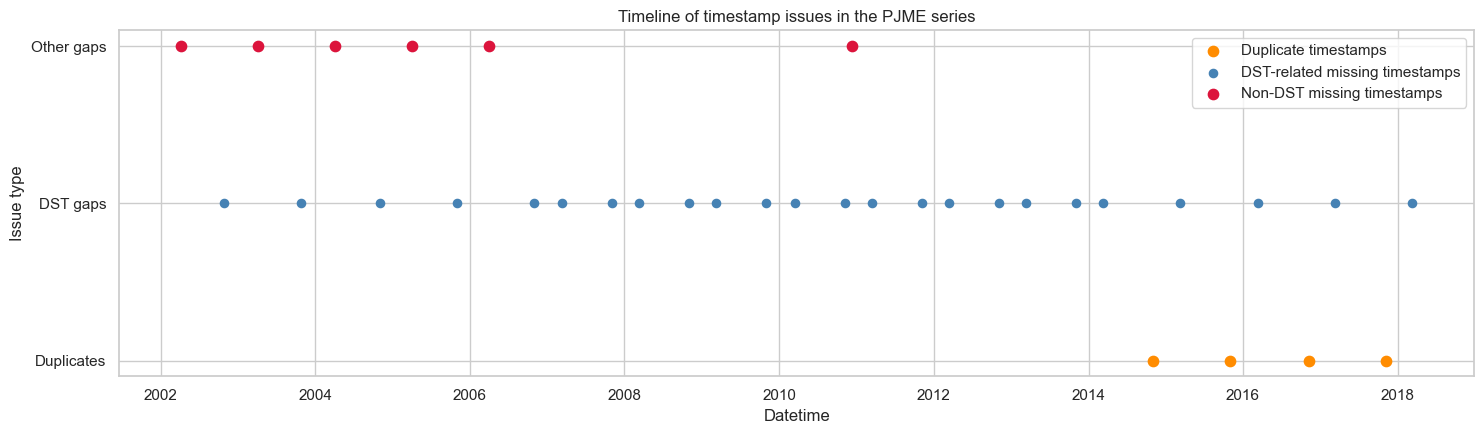

In [4]:
dst_missing = missing_events.loc[missing_events["event_type"] == "dst_transition_gap", "missing_timestamp"]
other_missing = missing_events.loc[missing_events["event_type"] == "non_dst_gap", "missing_timestamp"]

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.scatter(duplicate_timestamps, np.zeros(len(duplicate_timestamps)), color="darkorange", s=55, label="Duplicate timestamps")
ax.scatter(dst_missing, np.ones(len(dst_missing)), color="steelblue", s=35, label="DST-related missing timestamps")
ax.scatter(other_missing, np.full(len(other_missing), 2), color="crimson", s=55, label="Non-DST missing timestamps")

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["Duplicates", "DST gaps", "Other gaps"])
ax.set_title("Timeline of timestamp issues in the PJME series")
ax.set_xlabel("Datetime")
ax.set_ylabel("Issue type")
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "03_missing_timeline.png"), dpi=150, bbox_inches="tight")
plt.show()

The timeline confirms that the irregular timestamps are highly concentrated around recurring seasonal clock changes rather than spread randomly across the dataset. This supports using a simple targeted cleanup strategy instead of treating the series as if it had broad structural missingness.

In [5]:
df_dedup = df.groupby(level=0).mean()
regular_index = pd.date_range(df_dedup.index.min(), df_dedup.index.max(), freq="h", name="Datetime")
df_regular = df_dedup.reindex(regular_index)
df_imputed = df_regular.copy()

short_gap_index = pd.Index(
    missing_events.loc[missing_events["imputation_method"] == "forward_fill", "missing_timestamp"]
)
medium_gap_index = pd.Index(
    missing_events.loc[missing_events["imputation_method"] == "linear_interpolation", "missing_timestamp"]
)
long_gap_index = pd.Index(
    missing_events.loc[missing_events["imputation_method"] == "flag_long_gap", "missing_timestamp"]
)

ffill_candidates = df_imputed["PJME_MW"].ffill(limit=2)
df_imputed.loc[short_gap_index, "PJME_MW"] = ffill_candidates.loc[short_gap_index]

interp_candidates = df_imputed["PJME_MW"].interpolate(method="time", limit=24, limit_direction="both")
df_imputed.loc[medium_gap_index, "PJME_MW"] = interp_candidates.loc[medium_gap_index]

cleaning_summary = pd.DataFrame(
    {
        "metric": [
            "rows_after_duplicate_aggregation",
            "rows_after_regular_reindex",
            "short_gaps_filled_with_forward_fill",
            "medium_gaps_filled_with_interpolation",
            "long_gaps_flagged",
            "remaining_missing_values",
            "remaining_duplicate_timestamps",
        ],
        "value": [
            len(df_dedup),
            len(df_imputed),
            len(short_gap_index),
            len(medium_gap_index),
            len(long_gap_index),
            int(df_imputed["PJME_MW"].isna().sum()),
            int(df_imputed.index.duplicated().sum()),
        ],
    }
)

display(cleaning_summary)

,metric,value
0,rows_after_duplicate_aggregation,145362
1,rows_after_regular_reindex,145392
2,short_gaps_filled_with_forward_fill,30
3,medium_gaps_filled_with_interpolation,0
4,long_gaps_flagged,0
5,remaining_missing_values,0
6,remaining_duplicate_timestamps,0


Duplicate timestamps were averaged first because the repeated fall-back hour represents the same clock label occurring twice and we need one value per hourly slot. After that, the series was reindexed to a complete hourly calendar and all one-hour gaps were forward-filled, which follows the project rule for short gaps; no medium or long gaps were present, so interpolation and long-gap flagging were not needed in practice.

In [6]:
output_path = os.path.join(PROCESSED_PATH, "pjme_imputed.csv")
df_imputed.to_csv(output_path)

comparison_window = pd.DataFrame(
    {
        "original_mw": df_regular.loc["2010-12-09 22:00:00":"2010-12-10 02:00:00", "PJME_MW"],
        "imputed_mw": df_imputed.loc["2010-12-09 22:00:00":"2010-12-10 02:00:00", "PJME_MW"],
    }
)
comparison_window["was_missing"] = comparison_window["original_mw"].isna()

print("Saved cleaned dataset to ../data/processed/pjme_imputed.csv")
display(comparison_window)
print(f"Final shape: {df_imputed.shape}")
print(f"Remaining NaNs: {int(df_imputed['PJME_MW'].isna().sum())}")

Saved cleaned dataset to ../data/processed/pjme_imputed.csv


,original_mw,imputed_mw,was_missing
Datetime,,,
2010-12-09 22:00:00,40288.0,40288.0,False
2010-12-09 23:00:00,37729.0,37729.0,False
2010-12-10 00:00:00,NaN,37729.0,True
2010-12-10 01:00:00,33163.0,33163.0,False
2010-12-10 02:00:00,32323.0,32323.0,False


Final shape: (145392, 1)
Remaining NaNs: 0


The final dataset now has a continuous hourly index from `2002-01-01 01:00:00` to `2018-08-03 00:00:00` with no duplicate timestamps and no missing demand values. This cleaned file is ready for the stationarity checks in Step 4.